# Анализ сегментации клиентов для CRM-маркетинга

## Цель проекта

Изначальная задача была решена в SQL: для каждого клиента был рассчитан сегмент на основе количества доставленных заказов и давности регистрации.

В этом ноутбуке SQL-выгрузка используется как аналитический датасет для следующего шага: понять структуру клиентской базы и сформулировать гипотезы для персонализированных коммуникаций.

**Ключевые вопросы анализа:**

1. Какая структура клиентской базы по сегментам?
2. Какие сегменты формируют основную покупательскую активность?
3. Есть ли потенциал для реактивации клиентов без заказов?
4. Есть ли различия между городами?
5. Связана ли скорость доставки с повторными заказами?
6. Насколько стабилен приток новых регистраций?

**Исходная задача:**  
Проведите сегментацию клиентов по состоянию на **31 марта 2024**.  
Требуемые поля в выводе для каждого клиента: 
- customer_id,
- customer_city,
- registration_date (дата регистрации),
- days_since_registration (число дней с даты регистрации),
- orders_count (число доставленных заказов),
- purchase_events_count (число событий покупки — Purchase),
- avg_delivery_days (среднее время доставки в днях),
- segment (сегмент).

**Правила сегментации клиентов:**
| Сегмент | Стратегия коммуникации | Критерий формирования |
|---|---|---|
| **Постоянный** | Эксклюзивные предложения и программа лояльности | 3 и более доставленных заказа |
| **Разовый** | Напоминание о магазине и реактивация | 1 или 2 доставленных заказа |
| **Неактивный** | Специальные акции для возврата | 0 заказов, дата регистрации — более 30 дней назад |
| **Новый** | Приветствие и помощь с первой покупкой | 0 заказов, дата регистрации — 30 или менее дней назад |

## SQL-логика сегментации

<div class="alert alert-block alert-info">
<pre><code>
-- Формируем CTE (число доставленных заказов, среднее время доставки в днях)
WITH orders_data AS (
    SELECT customer_id, 
           COUNT(order_id) as orders_count, 
           AVG(
               EXTRACT(EPOCH FROM (order_delivered_customer_time - order_created_time)) / 86400
           ) as avg_delivery_days 
    FROM orders 
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
), 

-- Формируем CTE (число событий покупки — Purchase)
purchase_data AS (
    SELECT customer_id, 
           COUNT(event_timestamp) FILTER (WHERE event_type = 'Purchase') as purchase_events_count 
    FROM customer_actions
    GROUP BY customer_id
)

-- Итоговый запрос 
SELECT c.customer_id, c.customer_city, c.created_at AS registration_date, 
       DATE('2024-03-31') - c.created_at AS days_since_registration, 
       COALESCE(o.orders_count, 0) as orders_count, 
       COALESCE(p.purchase_events_count, 0) as purchase_events_count, 
       o.avg_delivery_days,
       CASE 
            WHEN o.orders_count >= 3 THEN 'Постоянный'
            WHEN o.orders_count >= 1 THEN 'Разовый'
            WHEN DATE('2024-03-31') - c.created_at > 30 THEN 'Неактивный'
            ELSE 'Новый'
       END as segment
FROM customers c 
LEFT JOIN orders_data o ON c.customer_id = o.customer_id
LEFT JOIN purchase_data p ON c.customer_id = p.customer_id;
</code></pre>
</div>

## 1. Загрузка данных и подготовка

Файл `segment_data_download.csv` — это результат SQL-запроса. В нем одна строка соответствует одному клиенту после агрегации истории заказов и событий.

In [119]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

segment_df = pd.read_csv('segment_data_download.csv')
segment_df.head()

,customer_id,customer_city,registration_date,days_since_registration,orders_count,purchase_events_count,avg_delivery_days,segment
0,1,Екатеринбург,01/01/24,90,0,0,NaN,Неактивный
1,2,Пермь,01/01/24,90,0,0,NaN,Неактивный
2,3,Ростов-на-Дону,01/01/24,90,2,4,4.647917,Разовый
3,4,Санкт-Петербург,01/01/24,90,0,0,NaN,Неактивный
4,5,Ижевск,01/01/24,90,0,0,NaN,Неактивный


In [120]:
# Размер датасета и типы данных
print(f'Количество строк: {segment_df.shape[0]:,}')
print(f'Количество столбцов: {segment_df.shape[1]}')

Количество строк: 10,000
Количество столбцов: 8


In [121]:
# Приводим дату регистрации к datetime.
# Формат указываем явно, чтобы избежать неоднозначной интерпретации дат.
segment_df['registration_date'] = pd.to_datetime(
    segment_df['registration_date'],
    format='%d/%m/%y'
)

segment_df.head()

,customer_id,customer_city,registration_date,days_since_registration,orders_count,purchase_events_count,avg_delivery_days,segment
0,1,Екатеринбург,2024-01-01,90,0,0,NaN,Неактивный
1,2,Пермь,2024-01-01,90,0,0,NaN,Неактивный
2,3,Ростов-на-Дону,2024-01-01,90,2,4,4.647917,Разовый
3,4,Санкт-Петербург,2024-01-01,90,0,0,NaN,Неактивный
4,5,Ижевск,2024-01-01,90,0,0,NaN,Неактивный


In [153]:
# Посмотрим за какое время у нас есть данные
print(f"Первая дата: {segment_df.registration_date.min().date()}")
print(f"Последняя дата: {segment_df.registration_date.max().date()}")
print(f"Временной промежуток в днях: {(segment_df.registration_date.max() - segment_df.registration_date.min()).days}") 

Первая дата: 2024-01-01
Последняя дата: 2024-03-31
Временной промежуток в днях: 90


## 2. Data validation: проверка качества выгрузки

Перед аналитикой важно проверить, что SQL-сегментация не дала логических ошибок: нет дублей по клиентам, правила сегментации соблюдены, а пропуски объяснимы бизнес-логикой.

In [122]:
missing_df = (segment_df.isna().sum() \
    .reset_index() \
    .rename(columns={'index': 'column', 0: 'missing_values'}))

missing_df['missing_share_%'] = (missing_df['missing_values'] / len(segment_df) * 100).round(2)
missing_df

,column,missing_values,missing_share_%
0,customer_id,0,0.00
1,customer_city,99,0.99
2,registration_date,0,0.00
3,days_since_registration,0,0.00
4,orders_count,0,0.00
5,purchase_events_count,0,0.00
6,avg_delivery_days,8042,80.42
7,segment,0,0.00


In [123]:
# Проверки на дубли и логику сегментации
print(f'Полных дублей среди данных: {segment_df.duplicated().sum()}')
print(f'Дублей по customer_id: {segment_df.duplicated(subset="customer_id").sum()}')

print(f'''
Проверка 1. У клиентов из сегментов "Неактивный" и "Новый" не должно быть доставленных заказов:
Найдено нарушений: {segment_df.query('segment in ("Неактивный", "Новый") and orders_count > 0').shape[0]}

Проверка 2. В сегменте "Постоянный" должно быть не менее 3 доставленных заказов:
Найдено нарушений: {segment_df.query('segment == "Постоянный" and orders_count < 3').shape[0]}

Проверка 3. В сегменте "Разовый" должно быть ровно 1 или 2 доставленных заказа:
Найдено нарушений: {segment_df.query('segment == "Разовый" and orders_count not in [1, 2]').shape[0]}

Проверка 4. В сегменте "Неактивный" должно быть более 30 дней с момента регистрации:
Найдено нарушений: {segment_df.query('segment == "Неактивный" and days_since_registration <= 30').shape[0]}

Проверка 5. В сегменте "Новый" должно быть 30 или менее дней с момента регистрации:
Найдено нарушений: {segment_df.query('segment == "Новый" and days_since_registration > 30').shape[0]}

Проверка 6. Среднее время доставки должно быть заполнено для всех клиентов с доставленными заказами:
Найдено нарушений: {segment_df[segment_df['avg_delivery_days'].isna() & (segment_df['orders_count'] > 0)].shape[0]}
''')

Полных дублей среди данных: 0
Дублей по customer_id: 0

Проверка 1. У клиентов из сегментов "Неактивный" и "Новый" не должно быть доставленных заказов:
Найдено нарушений: 0

Проверка 2. В сегменте "Постоянный" должно быть не менее 3 доставленных заказов:
Найдено нарушений: 0

Проверка 3. В сегменте "Разовый" должно быть ровно 1 или 2 доставленных заказа:
Найдено нарушений: 0

Проверка 4. В сегменте "Неактивный" должно быть более 30 дней с момента регистрации:
Найдено нарушений: 0

Проверка 5. В сегменте "Новый" должно быть 30 или менее дней с момента регистрации:
Найдено нарушений: 0

Проверка 6. Среднее время доставки должно быть заполнено для всех клиентов с доставленными заказами:
Найдено нарушений: 0



**Вывод по качеству данных**

- В датасете 10 000 строк, каждая строка соответствует уникальному клиенту.
- Полных дублей и дублей по `customer_id` нет.
- Для 99 клиентов отсутствует город.
- `avg_delivery_days` отсутствует у клиентов без доставленных заказов — это ожидаемо, так как среднее время доставки невозможно рассчитать без доставок.
- Нарушений правил сегментации не найдено.

Данные можно использовать для дальнейшей аналитики.


## 3. Обзор ключевых метрик

Перед подробным разбором соберем ключевые метрики по сегментам: размер сегмента, долю клиентов, количество доставленных заказов, долю заказов и количество событий покупки.

In [124]:
# Построим сводную таблицу по доле клиентов в каждом сегменте и основным метрикам
segment_order = ['Неактивный', 'Новый', 'Разовый', 'Постоянный']

segments_summary = (segment_df.groupby('segment', as_index=False) \
    .agg(customers=('customer_id', 'count'),
        total_orders=('orders_count', 'sum'),
        avg_orders_per_customer=('orders_count', 'mean'),
        purchase_events=('purchase_events_count', 'sum'),
        avg_delivery_days=('avg_delivery_days', 'mean')))

segments_summary['customers_share_%'] = (segments_summary['customers'] / segments_summary['customers'].sum() * 100).round(2)
segments_summary['orders_share_%'] = (segments_summary['total_orders'] / segments_summary['total_orders'].sum() * 100).round(2)
segments_summary['purchase_events_share_%'] = (segments_summary['purchase_events'] / segments_summary['purchase_events'].sum() * 100).round(2)

segments_summary

,segment,customers,total_orders,avg_orders_per_customer,purchase_events,avg_delivery_days,customers_share_%,orders_share_%,purchase_events_share_%
0,Неактивный,4828,0,0.000000,1316,NaN,48.28,0.00,30.53
1,Новый,3214,0,0.000000,197,NaN,32.14,0.00,4.57
2,Постоянный,96,303,3.156250,311,4.710166,0.96,11.95,7.21
3,Разовый,1862,2232,1.198711,2487,4.579780,18.62,88.05,57.69


## 4. Распределение клиентов по сегментам

Ответим на базовый бизнес-вопрос: из каких типов клиентов состоит клиентская база.

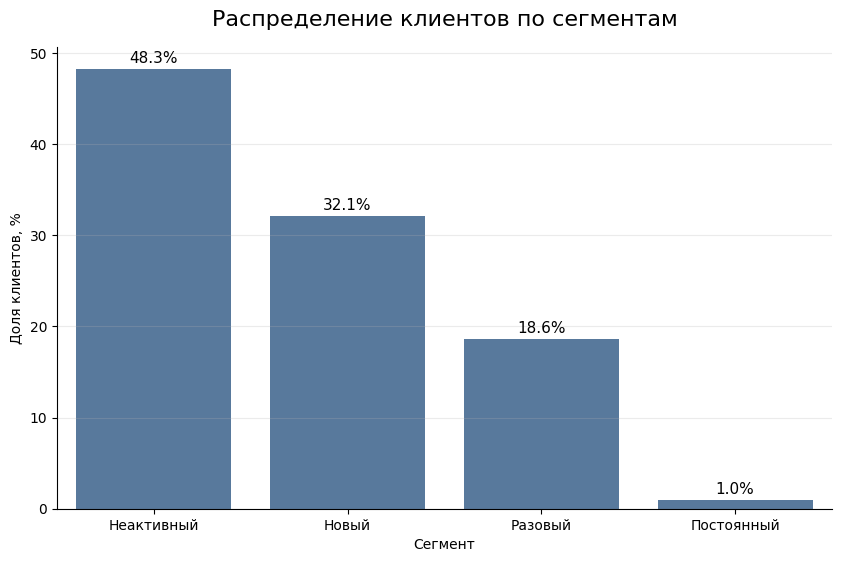

In [125]:
# Строим график на основе segments_summary
segments_plot = segments_summary.copy()
segments_plot = segments_plot.sort_values('customers_share_%', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(color='#4C78A8', data=segments_plot, x='segment', y='customers_share_%')

# Подписи над столбцами
ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%',
    padding=2,
    fontsize=11
)

plt.title('Распределение клиентов по сегментам', fontsize=16, pad=15)
plt.xlabel('Сегмент')
plt.ylabel('Доля клиентов, %')
plt.grid(axis='y', alpha=0.25)
sns.despine()
plt.show()

**Выводы:**

- Почти половина базы — неактивные клиенты;
- Новые клиенты составляют примерно треть базы;
- Разовые покупатели — заметный сегмент для развития повторных покупок;
- Постоянных клиентов очень мало — около 1%.



База сильно смещена в сторону клиентов без доставленных заказов: `Неактивный` + `Новый` — около 80% всех клиентов. При этом почти все доставленные заказы формируются сегментами `Разовый` и `Постоянный`.

Это означает, что маркетинговая стратегия должна решать две разные задачи:

1. **Активация клиентов без заказов** — особенно неактивных пользователей.
2. **Развитие повторных покупок** — перевод разовых покупателей в постоянные.



## 5. Заказы и покупательская активность по сегментам

Так как в выгрузке нет выручки, в качестве прокси-метрики ценности сегмента будем использовать количество доставленных заказов.


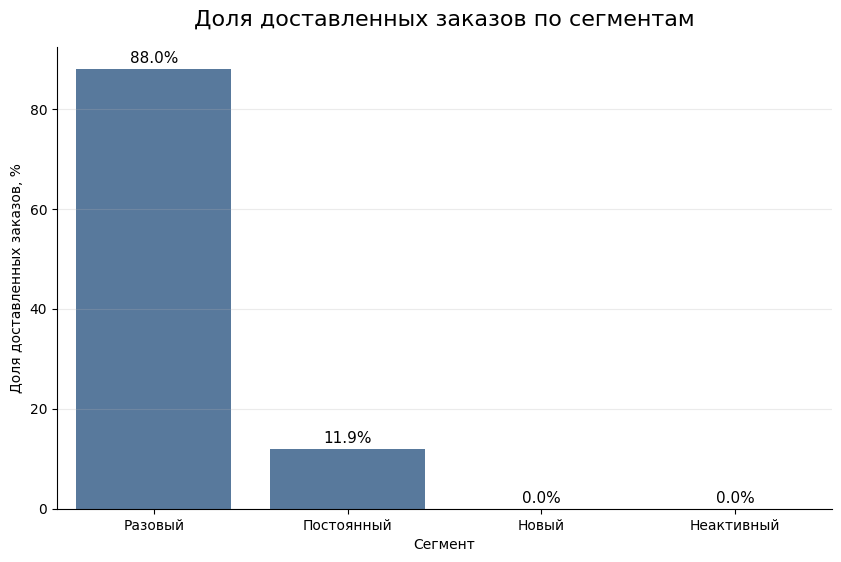

In [126]:
orders_plot = segments_summary.sort_values('orders_share_%', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(color='#4C78A8', data=orders_plot, x='segment', y='orders_share_%')

# Подписи над столбцами
ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%',
    padding=2,
    fontsize=11
)

plt.title('Доля доставленных заказов по сегментам', fontsize=16, pad=15)
plt.xlabel('Сегмент')
plt.ylabel('Доля доставленных заказов, %')
plt.grid(axis='y', alpha=0.25)
sns.despine()
plt.show()

**Вывод**

- Основной объем доставленных заказов формируют `Разовые` клиенты.
- `Постоянные` клиенты занимают менее 1% базы, но дают заметную долю заказов.
- Это подтверждает ценность удержания: даже маленький сегмент постоянных клиентов непропорционально важен для бизнеса.

**Гипотеза:** сфокусироваться на клиентах с 1–2 доставленными заказами и стимулировать следующий заказ, потому что это самый близкий путь к росту сегмента `Постоянный`.


## 6. События покупки без доставленных заказов

В данных есть `purchase_events_count` — количество событий типа `Purchase`. Оно может быть больше количества доставленных заказов, потому что событие покупки и факт доставленного заказа — разные этапы воронки.

Проверим клиентов, у которых были события покупки, но нет доставленных заказов (при этом важно понимать, что часть заказов могла быть в пути на время выгрузки).

In [127]:
# Добавим флаг для клиентов с недоставленными / незавершенными заказами
segment_df['has_undelivered_orders'] = (segment_df['purchase_events_count'] > segment_df['orders_count'])

# Доля таких клиентов внутри сегментов
undelivered_by_segment = (segment_df.groupby('segment', as_index=False) \
    .agg(customers=('customer_id', 'count'),
        problematic_customers=('has_undelivered_orders', 'sum')))

undelivered_by_segment['percentage'] = (undelivered_by_segment['problematic_customers'] / undelivered_by_segment['customers'] * 100).round(1)

undelivered_by_segment

,segment,customers,problematic_customers,percentage
0,Неактивный,4828,1066,22.1
1,Новый,3214,163,5.1
2,Постоянный,96,5,5.2
3,Разовый,1862,186,10.0


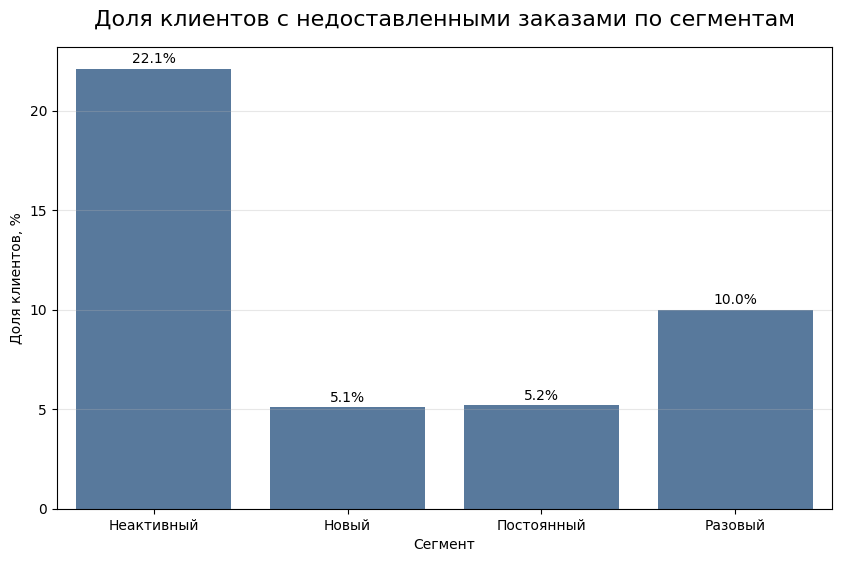

In [128]:
# Построим график
plt.figure(figsize=(10, 6))

ax = sns.barplot(color='#4C78A8', data=undelivered_by_segment, x='segment', y='percentage')

plt.title('Доля клиентов с недоставленными заказами по сегментам', fontsize=16, pad=15)
plt.xlabel('Сегмент')
plt.ylabel('Доля клиентов, %')

# Подписи над столбцами
ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%',
    padding=2
)

plt.grid(axis='y', alpha=0.3)
plt.show()

**Вывод**  
Для всех категорий клиентов присутствует доля недоставленных заказов, поскольку часть заказов всегда будет находиться в пути на момент выгрузки.  

При этом наибольшая и существенная доля клиентов с недоставленными заказами наблюдается в сегменте `Неактивных` и `Разовых` клиентов. Это может указывать на то, что негативный опыт взаимодействия с сервисом снижает вероятность повторных покупок.



In [129]:
# Посмотрим на долю клиентов с недоставленными заказами в разбивке по городам
city_issues = (segment_df.query('customer_city.notna()') \
    .groupby('customer_city', as_index=False) \
    .agg(customers=('customer_id', 'count'),
         problematic_customers=('has_undelivered_orders', 'sum')))

city_issues['percentage'] = (city_issues['problematic_customers'] / city_issues['customers'] * 100).round(1)

# Исключаем города с маленьким количеством клиентов
city_issues = city_issues.query('customers >= 50')

top_problem_cities = (city_issues.sort_values('percentage', ascending=False).head(10))

top_problem_cities

,customer_city,customers,problematic_customers,percentage
12,Ростов-на-Дону,502,123,24.5
6,Красноярск,521,126,24.2
13,Самара,520,112,21.5
7,Москва,492,93,18.9
19,Челябинск,489,70,14.3
14,Санкт-Петербург,504,70,13.9
8,Нижний Новгород,517,70,13.5
2,Екатеринбург,510,69,13.5
3,Ижевск,514,68,13.2
10,Омск,484,64,13.2


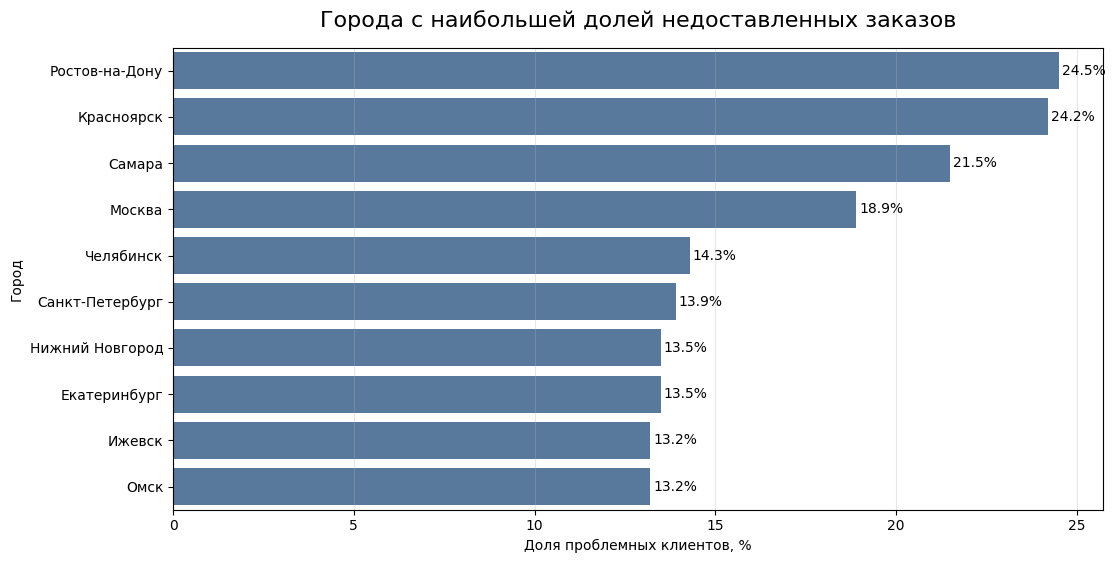

In [130]:
# Построим график
plt.figure(figsize=(12, 6))

ax = sns.barplot(color='#4C78A8', data=top_problem_cities, x='percentage', y='customer_city')

plt.title('Города с наибольшей долей недоставленных заказов', fontsize=16, pad=15)
plt.xlabel('Доля проблемных клиентов, %')
plt.ylabel('Город')

# Подписи над столбцами
ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%',
    padding=2
)

plt.grid(axis='x', alpha=0.3)
plt.show()

### Бизнес-вывод

Анализ показал, что в отдельных городах доля клиентов с недоставленными заказами существенно выше средней.

Это может говорить о проблемах с логистикой в конкретном регионе или нестабильной работе доставки.
Такие города требуют дополнительного мониторинга и более детального анализа причин недоставки заказов.

## 7. Динамика регистраций

Так как датасет содержит информацию только за 3 месяца, месячный временной ряд будет слишком грубым. Поэтому проанализируем динамику по дням и добавим 7-дневное скользящее среднее, чтобы отделить шум от общего тренда.

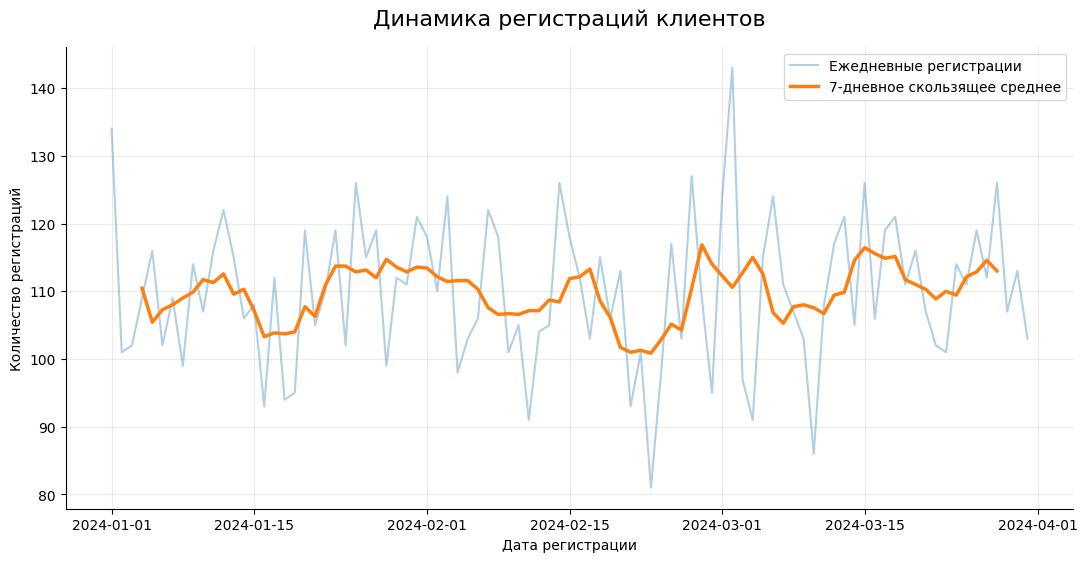

count     91.000000
mean     109.890110
std       10.740836
min       81.000000
25%      103.000000
50%      110.000000
75%      117.500000
max      143.000000
Name: registrations, dtype: float64

In [131]:
# Формируем таблицу с количеством регистраций на каждую дату
registrations_df = (segment_df.groupby('registration_date', as_index=False) \
    .agg(registrations=('customer_id', 'count')) \
    .sort_values('registration_date')
)

# Добавляем скользящее среднее
registrations_df['registrations_ma_7'] = (registrations_df['registrations'].rolling(window=7, center=True).mean())


# Строим график
plt.figure(figsize=(13, 6))

# Основной временной ряд
sns.lineplot(data=registrations_df, x='registration_date', y='registrations', label='Ежедневные регистрации', alpha=0.35)

# Скользящее среднее
sns.lineplot(data=registrations_df, x='registration_date', y='registrations_ma_7', label='7-дневное скользящее среднее', linewidth=2.5)

plt.title('Динамика регистраций клиентов', fontsize=16, pad=15)
plt.xlabel('Дата регистрации')
plt.ylabel('Количество регистраций')
plt.grid(alpha=0.25)
sns.despine()
plt.show()

# Дополнительная информация
registrations_df['registrations'].describe()

**Вывод**

Приток новых клиентов выглядит стабильным: выраженного роста или падения регистраций не видно. Ежедневные значения шумные, но 7-дневное среднее остается в сравнительно узком диапазоне.

## 8. География покупателей

Срез по городам пользователей поможет понять, где сосредоточена клиентская база и где есть проблемы с конверсией в повторные заказы.

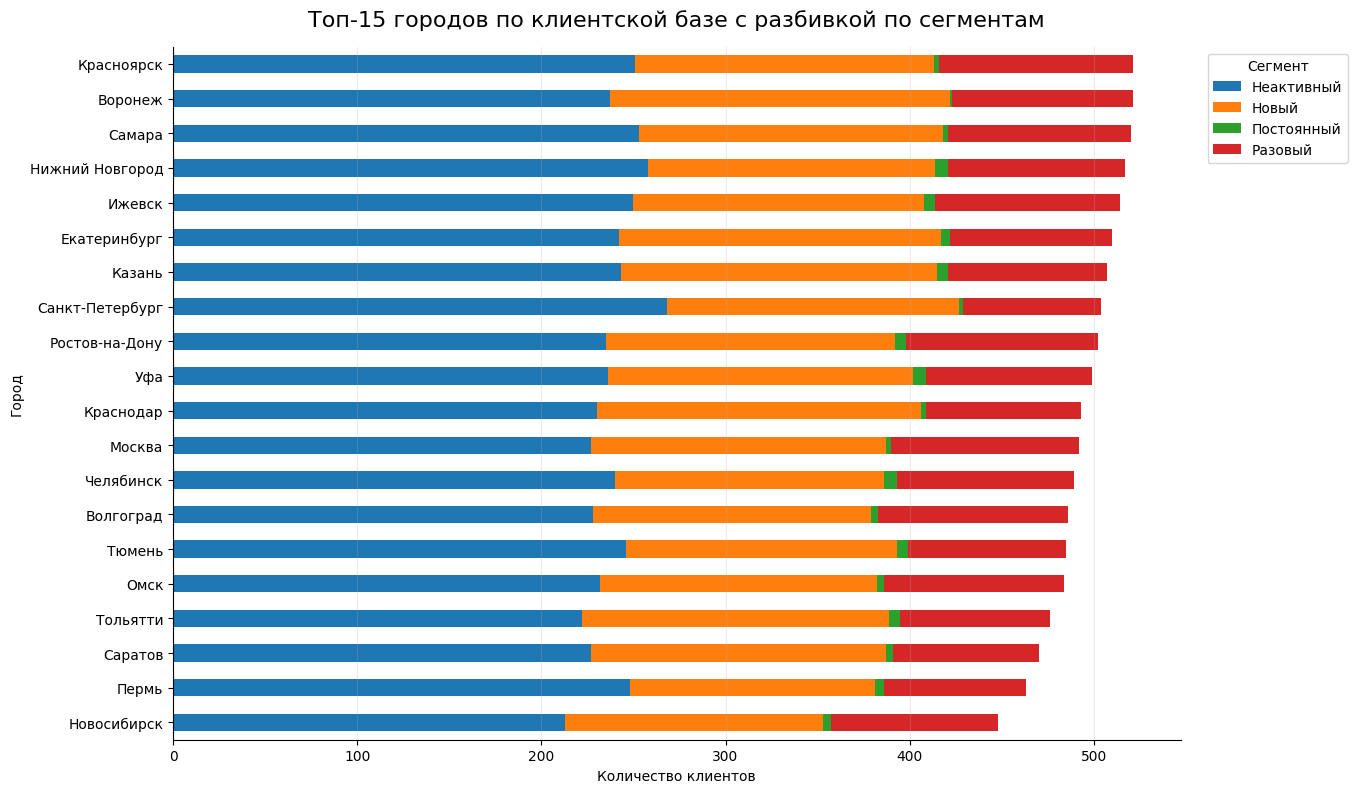

In [132]:
# Разобьем данные по городу и сегменту
city_df = segment_df.groupby(['customer_city', 'segment'], as_index=False) \
    .agg(customers_by_segment = ('customer_id','count'))

# Добавим столбец с общим количеством покупателей для города
city_df['customers_total'] = city_df.groupby('customer_city')['customers_by_segment'].transform('sum')

# сделаем сводную таблицу для графика (сегменты превращаем из строк в колонки)
city_df_pivot = city_df.pivot(index='customer_city', columns='segment', values='customers_by_segment') 

# добавляем total для сортировки значений в сводной таблице
city_df_pivot['total'] = city_df_pivot.sum(axis=1)
city_df_pivot = city_df_pivot.sort_values('total', ascending=True) 
city_df_pivot = city_df_pivot.drop(columns='total')

# строим график 
city_df_pivot.plot(kind='barh', stacked=True, figsize=(13, 9))

plt.title('Топ-15 городов по клиентской базе с разбивкой по сегментам', fontsize=16, pad=15)
plt.xlabel('Количество клиентов')
plt.ylabel('Город')
plt.legend(title='Сегмент', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='x', alpha=0.25)
sns.despine()
plt.show()

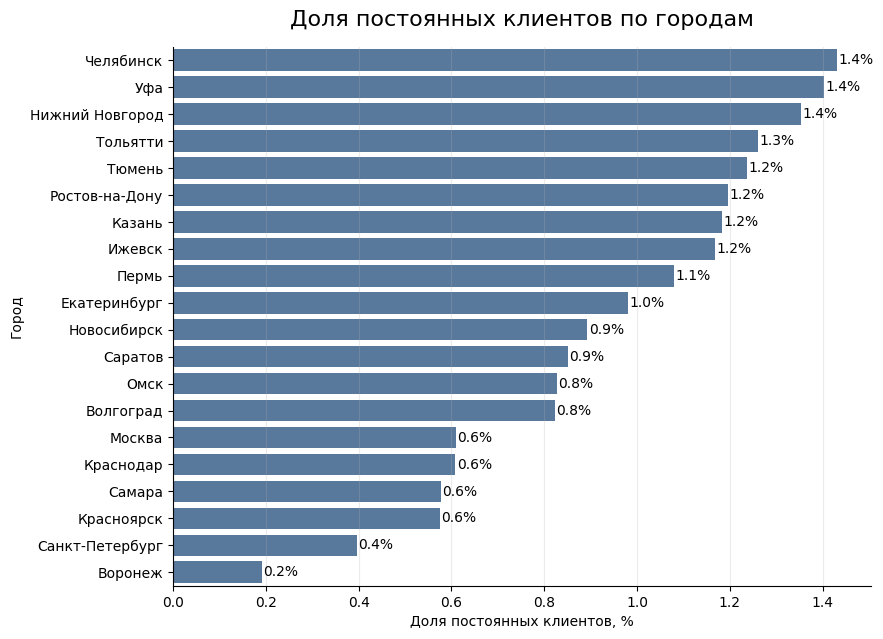

In [133]:
# Добавляем столбец с долей сегмента от общего количества пользователей
city_df['segment_ratio'] = city_df['customers_by_segment']/city_df['customers_total']*100

# Строим график по постоянным клиентам
plt.figure(figsize=(9,7))

ax = sns.barplot(color='#4C78A8', data = city_df.query('segment == "Постоянный"').sort_values('segment_ratio', ascending = False), 
            y = 'customer_city', x = 'segment_ratio')


# Подписи над столбцами
ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%',
    padding=1
)

plt.title('Доля постоянных клиентов по городам', fontsize=16, pad=15)
plt.xlabel('Доля постоянных клиентов, %')
plt.ylabel('Город')
plt.grid(axis='x', alpha=0.25)
sns.despine()
plt.show()

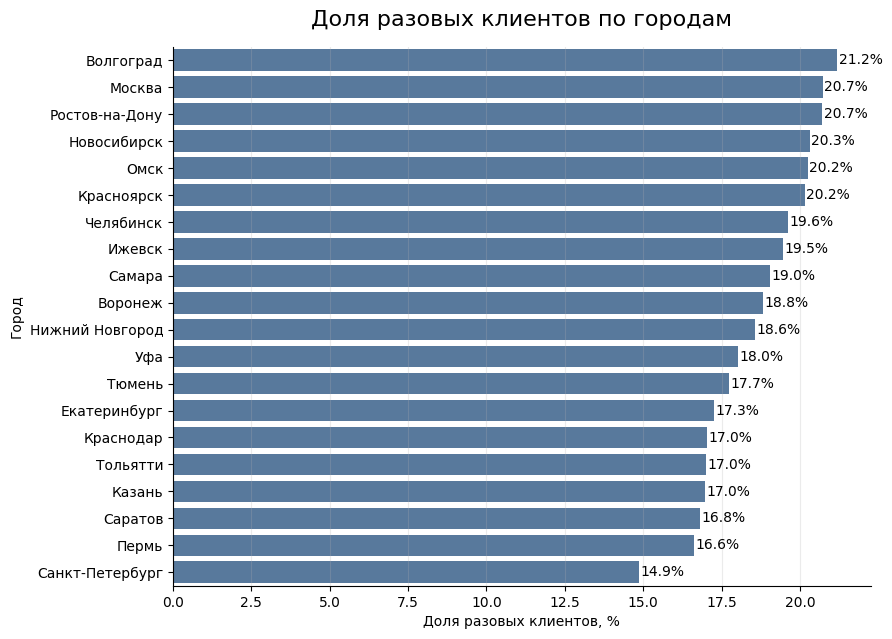

In [134]:
# Строим график по разовым клиентам
plt.figure(figsize=(9,7))

ax = sns.barplot(color='#4C78A8', data = city_df.query('segment == "Разовый"').sort_values('segment_ratio', ascending = False), 
            y = 'customer_city', x = 'segment_ratio')


# Подписи над столбцами
ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%',
    padding=1
)

plt.title('Доля разовых клиентов по городам', fontsize=16, pad=15)
plt.xlabel('Доля разовых клиентов, %')
plt.ylabel('Город')
plt.grid(axis='x', alpha=0.25)
sns.despine()
plt.show()

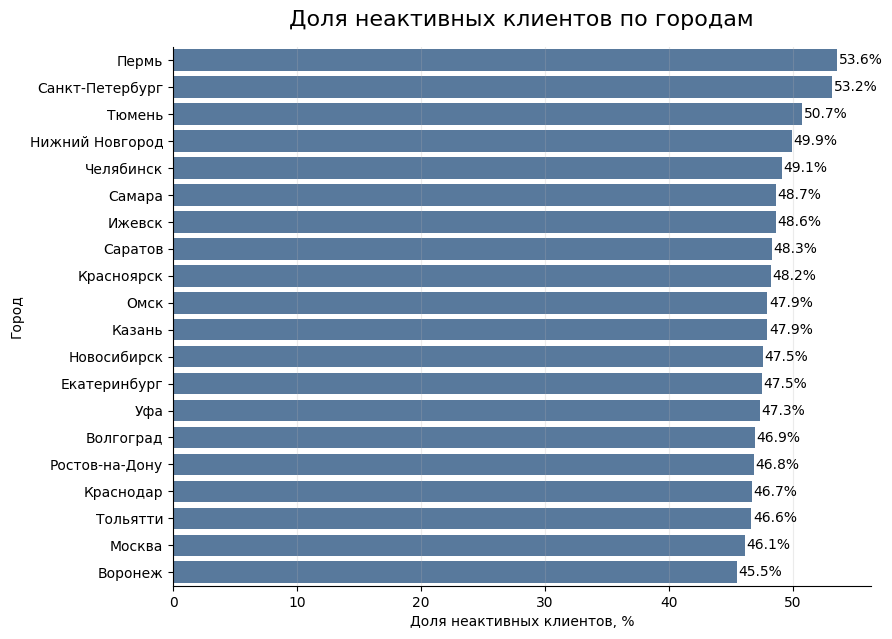

In [135]:
# Строим график по неактивным клиентам
plt.figure(figsize=(9,7))

ax = sns.barplot(color='#4C78A8', data = city_df.query('segment == "Неактивный"').sort_values('segment_ratio', ascending = False), 
            y = 'customer_city', x = 'segment_ratio')


# Подписи над столбцами
ax.bar_label(
    ax.containers[0],
    fmt='%.1f%%',
    padding=1
)

plt.title('Доля неактивных клиентов по городам', fontsize=16, pad=15)
plt.xlabel('Доля неактивных клиентов, %')
plt.ylabel('Город')
plt.grid(axis='x', alpha=0.25)
sns.despine()
plt.show()

**Вывод по городам**

- Города сопоставимы по размеру клиентской базы, поэтому корректнее сравненивать доли сегментов, чем абсолютные значения.
- В некоторых городах доля постоянных клиентов выше среднего, в других — почти отсутствует (требует дальнейшего анализа).
- Города с высокой долей неактивных клиентов — кандидаты для локальных реактивационных кампаний.
- Города с высокой долей разовых клиентов — кандидаты для кампаний на повторную покупку.

## 9. Доставка и повторные заказы

Проверим, отличается ли среднее время доставки у разовых и постоянных клиентов. Это продуктовая гипотеза: если доставка медленная, клиент может реже возвращаться.


In [136]:
# Подготовим отчет по времени доставки в разных сегментах (где уместно)
delivery_df = segment_df.dropna(subset=['avg_delivery_days']).copy()

delivery_by_segment = (delivery_df.groupby('segment', as_index=False) \
    .agg(customers=('customer_id', 'count'),
        avg_delivery_days=('avg_delivery_days', 'mean'),
        median_delivery_days=('avg_delivery_days', 'median'),
        avg_orders_per_customer=('orders_count', 'mean')) \
    .sort_values('avg_delivery_days')
)

delivery_by_segment

,segment,customers,avg_delivery_days,median_delivery_days,avg_orders_per_customer
1,Разовый,1862,4.579780,4.618056,1.198711
0,Постоянный,96,4.710166,4.517737,3.156250


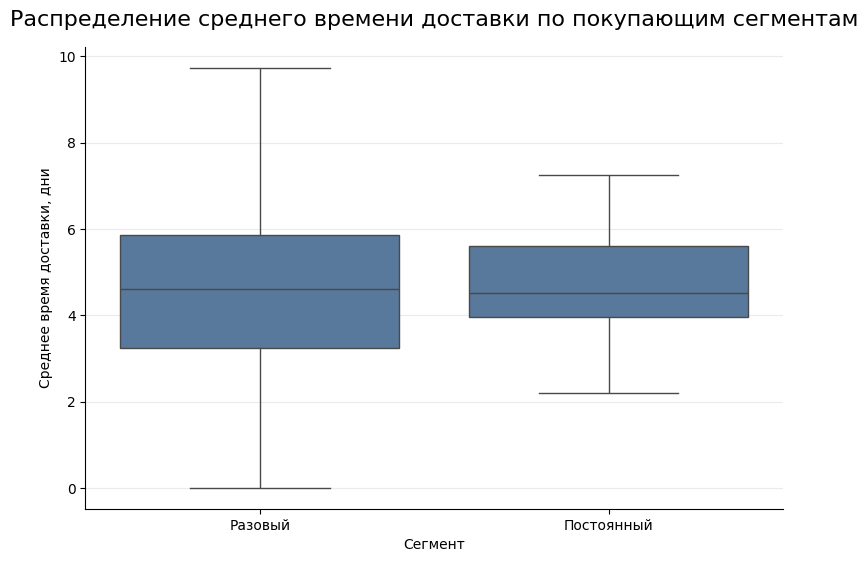

In [137]:
# Построим боксплот для наглядности
plt.figure(figsize=(9, 6))

ax = sns.boxplot(color='#4C78A8', data=delivery_df, x='segment', y='avg_delivery_days', order=['Разовый', 'Постоянный'])

plt.title('Распределение среднего времени доставки по покупающим сегментам', fontsize=16, pad=15)
plt.xlabel('Сегмент')
plt.ylabel('Среднее время доставки, дни')
plt.grid(axis='y', alpha=0.25)
sns.despine()
plt.show()

**Вывод**

По текущей агрегированной выгрузке сильной связи между средним временем доставки и количеством заказов не видно. Среднее время доставки у разовых и постоянных клиентов близкое.

Для более достоверной проверки гипотезы нужны данные по каждому заказу, статусам отмен, категориям товаров, срокам обещанной доставки и повторным покупкам после конкретной доставки.

## 10. Финальные выводы и рекомендации

### Основные выводы

1. **База сильно смещена в сторону клиентов без доставленных заказов.**  
   `Неактивные` и `Новые` клиенты составляют основную часть базы.

2. **Наибольшее число заказов генерируют разовые клиенты.**
   `Разовые` клиенты формируют основную массу доставленных заказов, сегмент `Постоянных` клиентов достатчно небольшой, но имеет высокую ценность.
   
3. **Есть отдельная аудитория для расследования воронки.**  
   В сегментах `Неактивные` и `Разовые` наблюдается повышенная доля клиентов с недоставленными заказами. Это может указывать на то, что негативный опыт взаимодействия с сервисом снижает вероятность повторных покупок. Необходимо проверить бизнес-процесс на наличие проблем между purchase-событием и успешной доставкой.

4. **Региональные проблемы с доставкой.**  
   В ходе анализа были обнаружены региональные особенности - города с повышенной долей недоставленных заказов. Требует дальнейшего анализа логистики или клиентского пути.

5. **Приток регистраций стабилен.**  
   Поэтому следующая аналитическая задача - не только рост регистраций, но и повышение конверсии новых пользователей в первый заказ и повторные покупки.

6. **География может использоваться для приоритизации маркетинговых кампаний.**  
   Разные города отличаются по доле постоянных, разовых и неактивных клиентов.

### Рекомендации

- Проведение маркетинговых кампаний:
    - Для Неактивных: реактивационные кампании, особенно для тех, у кого были purchase-события.
    - Для клиентов с 1 и 2 заказами: персональное предложение для перехода в постоянные.
- Анализ бизнес-процессов совершения покупки и доставки товаров на наличие проблем.
- Мониторинг "проблемных" городов с высокой долей незавершенных заказов. 